# TrayectoriasAfro Network Description

These are operations that help to describe the Trayectorias Afro network overall shape

## Dependencies

In [1]:
import pandas as pd
from pathlib import Path
import networkx as nx
import collections
import matplotlib.pyplot as plt
import numpy as np
import json

## Helper functions

### Design notes

#### Connected component strategy

Several metrics cannot be computed on the full graph and require a connected subgraph. Two different subgraphs are used depending on the metric:

| Subgraph | Function | Used for |
|---|---|---|
| **Largest (Weakly) Connected Component — LCC** | `_get_lcc` | `lcc_size` — structural measure of overall reachability |
| **Largest *Strongly* Connected Component — LSCC** | `_get_lscc` | `average_path_length`, `diameter` — require that every node can reach every other node via directed paths |

For **undirected graphs** both functions return the same thing (the standard LCC).  
For **directed graphs** (e.g. `sub` relations), weak connectivity only guarantees a path exists if you ignore edge direction, so path-based metrics would raise `NetworkXError: Graph is not strongly connected`. The LSCC is used instead, and both `average_path_length` and `diameter` report `computed_on_nodes` alongside their value so it is always clear how much of the graph the metric actually covers.

#### `sujeto_col` semantics (pending backend rename)

In `relaciones_personas.csv`, the column `persona_sujeto_idno` currently stores the **owner/enslaver** (the dominant party), not the enslaved/subordinated person as the name might suggest. Until the upstream data is corrected, passing `sujeto_col='persona_sujeto_idno'` to `graph_description` treats that column as the **edge source** (owner → subject).


In [2]:
def describe_cent(centrality_cal: dict, all: bool = False) -> dict:
    """Simple function, just to perform basic description and format the output to a dict"""
    keys = []
    values = []
    
    for k,v in centrality_cal.items():
        keys.append(k)
        values.append(v)
        
    cent = pd.DataFrame({'persona': keys, 'centrality': values})
    description = cent.describe().to_dict()
    if all:
        return description['centrality']
    return {
        'mean': description['centrality'].get('mean'),
        'std': description['centrality'].get('std'),
        'min': description['centrality'].get('min'),
        'max': description['centrality'].get('max')
    }



In [3]:
## Networkx helper functions

_STYLE = 'seaborn-v0_8-whitegrid'

def av_degree(G):
    return sum(dict(G.degree()).values()) / G.number_of_nodes()

# --- Degree histogram ---
def degree_dist(G, subgroup: str|None, save: bool = True, report_dir: str = 'report'):
    degree_sequence = sorted([d for n, d in G.degree()], reverse=True)
    degreeCount = collections.Counter(degree_sequence)
    deg, cnt = zip(*degreeCount.items())
    
    suffix = f'_{subgroup}' if subgroup else ''

    with plt.style.context(_STYLE):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(deg, cnt, color='steelblue', edgecolor='white', linewidth=0.4)
        ax.set_yscale('log')
        ax.set_title(f'Degree Distribution{suffix}', fontsize=14, fontweight='bold', pad=12)
        ax.set_ylabel('Count (log scale)', fontsize=11)
        ax.set_xlabel('Degree', fontsize=11)

        # Only label ticks that are at least 2 apart to avoid clutter
        max_deg = max(deg)
        step = max(1, max_deg // 20)
        shown = [d for d in deg if d % step == 0 or d == max_deg]
        ax.set_xticks(shown)
        ax.set_xticklabels(shown, fontsize=8)

        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y):,}'))
        fig.tight_layout()

        if save:
            Path(report_dir).mkdir(exist_ok=True, parents=True)
            fig.savefig(Path(report_dir, f'degree_histogram{suffix}.png'), dpi=150)

    return fig

# --- CCDF plot ---
def degree_ccdf(G, subgroup: str|None, save: bool = True, report_dir: str = 'report'):
    degrees = np.array(sorted([d for n, d in G.degree()]))
    n = len(degrees)
    unique_deg, counts = np.unique(degrees, return_counts=True)
    cdf = np.cumsum(counts) / n          # P(X <= k)
    ccdf = 1 - cdf                       # P(X > k)

    suffix = f'_{subgroup}' if subgroup else ''

    with plt.style.context(_STYLE):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(unique_deg, ccdf, marker='o', markersize=4,
                linewidth=1.2, color='steelblue', markerfacecolor='white')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'Degree CCDF{suffix}  $P(X > k)$', fontsize=14, fontweight='bold', pad=12)
        ax.set_ylabel('$P(X > k)$', fontsize=11)
        ax.set_xlabel('Degree $k$ (log scale)', fontsize=11)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
        fig.tight_layout()

        if save:
            Path(report_dir).mkdir(exist_ok=True, parents=True)
            fig.savefig(Path(report_dir, f'degree_ccdf{suffix}.png'), dpi=150)

    return fig

def _get_lcc(G):
    """Largest weakly/undirected connected component — used for lcc_size."""
    if G.is_directed():
        components = nx.weakly_connected_components(G)
    else:
        components = nx.connected_components(G)
    return G.subgraph(max(components, key=len)).copy()

def _get_lscc(G):
    """Largest strongly connected component for DiGraphs, or LCC for undirected.
    Required by average_path_length and diameter, which need full reachability."""
    if G.is_directed():
        components = nx.strongly_connected_components(G)
    else:
        components = nx.connected_components(G)
    return G.subgraph(max(components, key=len)).copy()

def av_path_lenght(G):
    G_sub = _get_lscc(G)
    return {
        'value': nx.average_shortest_path_length(G_sub),
        'computed_on_nodes': G_sub.number_of_nodes(),
    }

def lcc_size(G):
    G_lcc = _get_lcc(G)
    size = G_lcc.number_of_nodes()
    return {'nodes': size, 'fraction': round(size / G.number_of_nodes(), 4)}

def clustering_coeff(G):
    return {
        'average_local': nx.average_clustering(G),
        'global_transitivity': nx.transitivity(G)
    }

def diameter(G):
    G_sub = _get_lscc(G)
    return {
        'value': nx.diameter(G_sub),
        'computed_on_nodes': G_sub.number_of_nodes(),
    }

def top_central_nodes(centrality_cal: dict, n: int = 10) -> list:
    sorted_nodes = sorted(centrality_cal.items(), key=lambda x: x[1], reverse=True)
    return [{'persona': k, 'centrality': round(v, 6)} for k, v in sorted_nodes[:n]]


In [4]:
def graph_description(
    pr_df: pd.DataFrame, 
    source: str = 'persona_idno_1',
    target: str = 'persona_idno_2',
    subgroup: str|None = None, 
    save: bool = True, 
    GraphType: str = 'NonDir', 
    report_dir: str = 'report', 
    n_central: int = 10,
    sujeto_col: str|None = None):
    """
    sujeto_col: when building a directed graph, the column that identifies
                the dominant party (owner/enslaver). Used as the edge source.
                The other person (whichever of source/target is not sujeto_col)
                becomes the edge target (enslaved/subordinated person).
                NOTE: to be renamed once the backend column name is corrected.
    """
    if subgroup:
        pr_df = pr_df.loc[pr_df['naturaleza_relacion'] == str(subgroup)].copy()

    if GraphType == 'Dir':
        if sujeto_col and sujeto_col in pr_df.columns:
            # Drop rows with unknown dominant party
            pr_df = pr_df.dropna(subset=[sujeto_col]).copy()
            # Derive the other person: whichever of source/target is NOT sujeto_col
            pr_df['_other'] = pr_df.apply(
                lambda r: r[target] if r[sujeto_col] == r[source] else r[source],
                axis=1
            )
            G = nx.from_pandas_edgelist(pr_df, sujeto_col, '_other', create_using=nx.DiGraph())
        else:
            G = nx.from_pandas_edgelist(pr_df, source, target, create_using=nx.DiGraph())
        n_components = nx.number_weakly_connected_components(G)
    else:
        G = nx.from_pandas_edgelist(pr_df, source, target)
        n_components = nx.number_connected_components(G)

    density = nx.density(G)
    degree_dist(G, subgroup, save, report_dir)
    degree_ccdf(G, subgroup, save, report_dir)

    # Compute centralities once
    dc = nx.degree_centrality(G)
    bc = nx.betweenness_centrality(G)
    cc = nx.closeness_centrality(G)

    report = {
        'nodes': len(G),
        'edges': G.number_of_edges(),
        'connected_components': n_components,
        'lcc_size': lcc_size(G),
        'density': density,
        'average_degree': av_degree(G),
        'clustering_coefficient': clustering_coeff(G),
        'average_path_length': av_path_lenght(G),
        'diameter': diameter(G),
        'degree_centrality': describe_cent(dc),
        'betweenness_centrality': describe_cent(bc),
        'closeness_centrality': describe_cent(cc),
        'top_degree_central': top_central_nodes(dc, n_central),
        'top_betweenness_central': top_central_nodes(bc, n_central),
        'top_closeness_central': top_central_nodes(cc, n_central),
    }
    
    if save:
        Path(report_dir).mkdir(exist_ok=True, parents=True)
        if subgroup:
            filename = Path(report_dir, f'report_{subgroup}.json')
        else:
            filename = Path(report_dir, 'report.json')
            
        with open(filename, 'w') as f:
            json.dump(report, f, ensure_ascii=False, indent=4)
    
    return report


## Data

In [5]:
deposit_data = '2026-05-08'
network_data = 'relaciones_personas.csv'

data = pd.read_csv(Path(deposit_data, network_data))
data.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 9701 entries, 0 to 9700
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   persona_idno_1        9701 non-null   str  
 1   persona_idno_2        9701 non-null   str  
 2   persona_relacion_id   9701 non-null   int64
 3   documento_idno        9701 non-null   str  
 4   naturaleza_relacion   9701 non-null   str  
 5   persona_sujeto_idno   8222 non-null   str  
 6   descripcion_relacion  1473 non-null   str  
dtypes: int64(1), str(6)
memory usage: 530.7 KB


## Overall Network Description

{'nodes': 7572,
 'edges': 9301,
 'connected_components': 930,
 'lcc_size': {'nodes': 1280, 'fraction': 0.169},
 'density': 0.00032448586904335037,
 'average_degree': 2.4566825145272055,
 'clustering_coefficient': {'average_local': 0.21000243275883074,
  'global_transitivity': 0.2942205014519},
 'average_path_length': {'value': 10.289683102032837,
  'computed_on_nodes': 1280},
 'diameter': {'value': 32, 'computed_on_nodes': 1280},
 'degree_centrality': {'mean': 0.0003244858690433503,
  'std': 0.000291821484745911,
  'min': 0.0001320829480914014,
  'max': 0.0073966450931184785},
 'betweenness_centrality': {'mean': 6.4350781229643e-05,
  'std': 0.00029894063368996013,
  'min': 0.0,
  'max': 0.009446102796481034},
 'closeness_centrality': {'mean': 0.005471467879984085,
  'std': 0.007475524714724416,
  'min': 0.0001320829480914014,
  'max': 0.026774064670233723},
 'top_degree_central': [{'persona': 'mx-sv-per-002059',
   'centrality': 0.007397},
  {'persona': 'mx-sv-per-000636', 'centrality

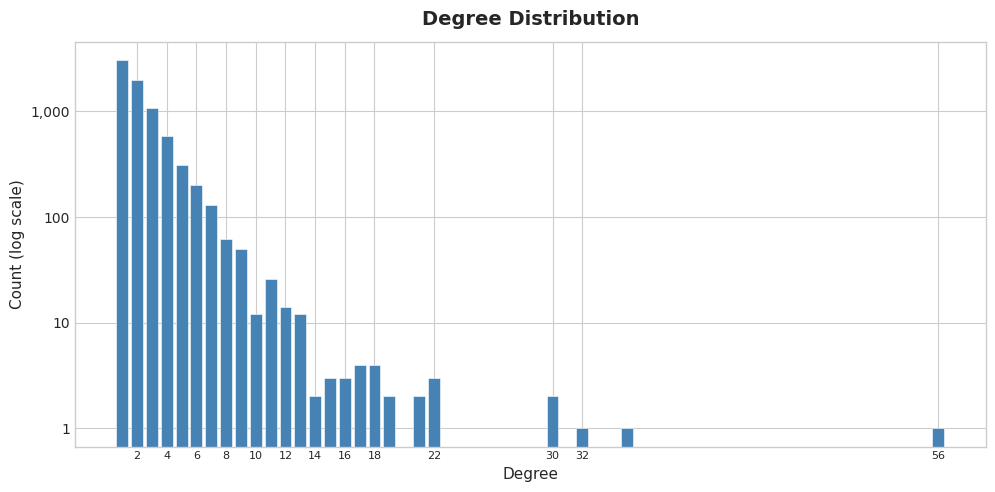

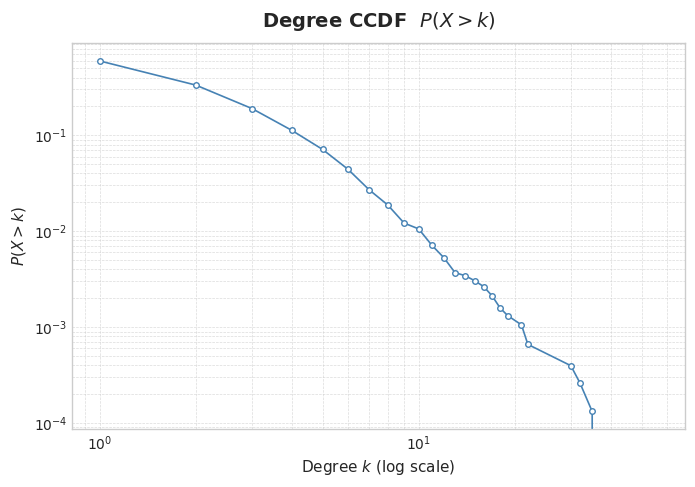

In [6]:
graph_description(data)

# Familial network

In [7]:
graph_description(data, subgroup='fam')

{'nodes': 1423,
 'edges': 1014,
 'connected_components': 615,
 'lcc_size': {'nodes': 8, 'fraction': 0.0056},
 'density': 0.001002220897788294,
 'average_degree': 1.4251581166549543,
 'clustering_coefficient': {'average_local': 0.23158652076431416,
  'global_transitivity': 0.9327485380116959},
 'average_path_length': {'value': 1.2142857142857142, 'computed_on_nodes': 8},
 'diameter': {'value': 2, 'computed_on_nodes': 8},
 'degree_centrality': {'mean': 0.0010022208977882943,
  'std': 0.0006432559572851891,
  'min': 0.0007032348804500703,
  'max': 0.004922644163150493},
 'betweenness_centrality': {'mean': 5.494883796120688e-08,
  'std': 3.3675973949625475e-07,
  'min': 0.0,
  'max': 5.9386478292757515e-06},
 'closeness_centrality': {'mean': 0.0010256739174518514,
  'std': 0.0006453024794877157,
  'min': 0.0007032348804500703,
  'max': 0.004922644163150493},
 'top_degree_central': [{'persona': 'mx-sv-per-001762',
   'centrality': 0.004923},
  {'persona': 'mx-sv-per-001856', 'centrality': 0

## Subordinate

In [8]:
graph_description(data, subgroup='sub', GraphType='Dir', sujeto_col='persona_sujeto_idno')


{'nodes': 7372,
 'edges': 8112,
 'connected_components': 841,
 'lcc_size': {'nodes': 1277, 'fraction': 0.1732},
 'density': 0.00014928501092364359,
 'average_degree': 2.200759631036354,
 'clustering_coefficient': {'average_local': 0.0, 'global_transitivity': 0},
 'average_path_length': {'value': 0, 'computed_on_nodes': 1},
 'diameter': {'value': 0, 'computed_on_nodes': 1},
 'degree_centrality': {'mean': 0.0002985700218472872,
  'std': 0.0002716779172419837,
  'min': 0.000135666802333469,
  'max': 0.007461674128340795},
 'betweenness_centrality': {'mean': 0.0, 'std': 0.0, 'min': 0.0, 'max': 0.0},
 'closeness_centrality': {'mean': 0.00014928501092364359,
  'std': 0.00023533601892571467,
  'min': 0.0,
  'max': 0.001763668430335097},
 'top_degree_central': [{'persona': 'mx-sv-per-002059',
   'centrality': 0.007462},
  {'persona': 'mx-sv-per-000636', 'centrality': 0.004748},
  {'persona': 'mx-sv-per-003005', 'centrality': 0.004341},
  {'persona': 'mx-sv-per-003454', 'centrality': 0.00407},


## Temp

In [9]:
graph_description(data, subgroup='tmp')

{'nodes': 248,
 'edges': 349,
 'connected_components': 73,
 'lcc_size': {'nodes': 10, 'fraction': 0.0403},
 'density': 0.011394802141831004,
 'average_degree': 2.814516129032258,
 'clustering_coefficient': {'average_local': 0.5675403225806451,
  'global_transitivity': 0.9298107255520505},
 'average_path_length': {'value': 1.0, 'computed_on_nodes': 10},
 'diameter': {'value': 1, 'computed_on_nodes': 10},
 'degree_centrality': {'mean': 0.011394802141831006,
  'std': 0.00917836670009958,
  'min': 0.004048582995951417,
  'max': 0.03643724696356275},
 'betweenness_centrality': {'mean': 2.0970237128256095e-05,
  'std': 7.456584988416167e-05,
  'min': 0.0,
  'max': 0.0005266449425627859},
 'closeness_centrality': {'mean': 0.012261052376149936,
  'std': 0.009085337887999428,
  'min': 0.004048582995951417,
  'max': 0.03643724696356275},
 'top_degree_central': [{'persona': 'mx-sv-per-000928',
   'centrality': 0.036437},
  {'persona': 'mx-sv-per-000929', 'centrality': 0.036437},
  {'persona': 'mx

## Associative

In [10]:
graph_description(data, subgroup='aso')

{'nodes': 66,
 'edges': 61,
 'connected_components': 23,
 'lcc_size': {'nodes': 9, 'fraction': 0.1364},
 'density': 0.02843822843822844,
 'average_degree': 1.8484848484848484,
 'clustering_coefficient': {'average_local': 0.27904040404040403,
  'global_transitivity': 0.6942148760330579},
 'average_path_length': {'value': 1.4166666666666667, 'computed_on_nodes': 9},
 'diameter': {'value': 2, 'computed_on_nodes': 9},
 'degree_centrality': {'mean': 0.02843822843822844,
  'std': 0.022455932548789206,
  'min': 0.015384615384615385,
  'max': 0.12307692307692308},
 'betweenness_centrality': {'mean': 0.00024038461538461537,
  'std': 0.0007888583212907374,
  'min': 0.0,
  'max': 0.005288461538461539},
 'closeness_centrality': {'mean': 0.033005474194285386,
  'std': 0.025355493370831386,
  'min': 0.015384615384615385,
  'max': 0.12307692307692308},
 'top_degree_central': [{'persona': 'mx-sv-per-003390',
   'centrality': 0.123077},
  {'persona': 'mx-sv-per-003431', 'centrality': 0.107692},
  {'per